#  - 72-Hour Recursive Forecasting Pipeline

## Objective
Implement an end-to-end recursive forecasting pipeline to predict Lahore AQI for the next 72 hours (3 days).

## Methodology: Recursive Autoregression
1. **Fetch current weather & air quality** to serve as the initial state ($T_0$).
2. **Fetch 72-hour weather forecasts** from the Open-Meteo API.
3. **Load the trained Ridge Regression model** from the local models registry.
4. **Iterate step-by-step** through the next 72 hours. For each hour, construct the feature vector using:
   - Dynamic time and cyclical features.
   - Future weather forecasts.
   - **Recursively computed** lag and rolling AQI values derived from our own previous predictions.
5. **Output**: Save predictions and generate the final dashboard-ready forecast plots.

In [1]:
import os
import json
import joblib
import warnings
import urllib.request
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Define paths
MODEL_DIR = Path("../models") if Path("../models").exists() else Path("models")
DATA_DIR = Path("../data/processed/lahore") if Path("../data/processed/lahore").exists() else Path("data/processed/lahore")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Imports successful.")
print("Model Directory :", MODEL_DIR.resolve())
print("Data Directory  :", DATA_DIR.resolve())

Imports successful.
Model Directory : D:\talha\Pearls_AQI_Predictor\models
Data Directory  : D:\talha\Pearls_AQI_Predictor\data\processed\lahore


In [2]:
print("Loading production model and configuration...")

# Load Ridge Regression Model
model_path = MODEL_DIR / "ridge_aqi_1h.pkl"
if not model_path.exists():
    raise FileNotFoundError(f"Model not found at {model_path}. Run notebook 06/07 first.")

model = joblib.load(model_path)
print("Loaded model type:", type(model))

# Define exact feature columns the model expects (must match Notebook 06)
FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "surface_pressure", 
    "precipitation", "cloud_cover", "wind_speed_10m", "wind_direction_10m",
    "pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone",
    "us_aqi", "hour", "day", "month", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "aqi_change_rate", "aqi_lag_1h", "aqi_lag_24h",
    "aqi_rolling_mean_6h", "aqi_rolling_std_6h", "pm25_rolling_mean_6h"
]

print(f"Model configured to accept {len(FEATURE_COLUMNS)} features.")

Loading production model and configuration...
Loaded model type: <class 'sklearn.linear_model._ridge.Ridge'>
Model configured to accept 29 features.


In [3]:
def fetch_weather_forecast(lat=31.5204, lon=74.3587):
    """Fetch hourly weather forecast for the next 3 days from Open-Meteo."""
    print(f"Fetching weather forecast for Latitude: {lat}, Longitude: {lon}...")
    
    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}&hourly="
        f"temperature_2m,relative_humidity_2m,surface_pressure,"
        f"precipitation,cloud_cover,wind_speed_10m,wind_direction_10m"
        f"&timezone=auto&forecast_days=3"
    )
    
    try:
        with urllib.request.urlopen(url) as response:
            data = json.loads(response.read().decode())
        
        hourly_data = data["hourly"]
        df = pd.DataFrame({
            "datetime": pd.to_datetime(hourly_data["time"]),
            "temperature_2m": hourly_data["temperature_2m"],
            "relative_humidity_2m": hourly_data["relative_humidity_2m"],
            "surface_pressure": hourly_data["surface_pressure"],
            "precipitation": hourly_data["precipitation"],
            "cloud_cover": hourly_data["cloud_cover"],
            "wind_speed_10m": hourly_data["wind_speed_10m"],
            "wind_direction_10m": hourly_data["wind_direction_10m"]
        })
        print(f"Successfully fetched {len(df)} hourly weather forecasts.")
        return df
    except Exception as e:
        print("Error fetching weather forecast:", e)
        return None

# Run fetch
weather_forecast_df = fetch_weather_forecast()
display(weather_forecast_df.head(3))

Fetching weather forecast for Latitude: 31.5204, Longitude: 74.3587...
Successfully fetched 72 hourly weather forecasts.


,datetime,temperature_2m,relative_humidity_2m,surface_pressure,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m
0,2026-08-20 00:00:00,28.5,92,979.1,0.0,5,6.9,95
1,2026-08-20 01:00:00,28.2,92,979.0,0.0,7,6.7,98
2,2026-08-20 02:00:00,28.0,93,978.5,0.0,22,7.3,99


In [4]:
# Load the preprocessed features dataset to get the most recent real hours
LOCAL_FEATURES_PATH = DATA_DIR / "lahore_features_hourly.csv"

if not LOCAL_FEATURES_PATH.exists():
    raise FileNotFoundError(f"Historical features not found at {LOCAL_FEATURES_PATH}")

historical_df = pd.read_csv(LOCAL_FEATURES_PATH, parse_dates=["datetime"])
historical_df = historical_df.sort_values("datetime").reset_index(drop=True)

# Extract the most recent 24 hours to use as context
context_history = historical_df.tail(24).copy()
print("Context dataset loaded.")
print("Most recent observation in history:", context_history["datetime"].max())
display(context_history[["datetime", "us_aqi", "pm2_5"]].tail(3))

Context dataset loaded.
Most recent observation in history: 2026-07-31 23:00:00


,datetime,us_aqi,pm2_5
22605,2026-07-31 21:00:00,114.354170,38.0
22606,2026-07-31 22:00:00,111.322914,37.8
22607,2026-07-31 23:00:00,109.031250,38.5


In [5]:
def add_time_features(df):
    """Compute cyclical temporal features for time-series alignment."""
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.day
    df["month"] = df["datetime"].dt.month
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)
    
    # Cyclical Transformations
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24.0)
    df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12.0)
    return df

In [7]:
print("Initializing recursive prediction horizon...")

# Prepare future dataframe starting with our 72-hour weather forecast
forecast_df = weather_forecast_df.copy()
forecast_df = add_time_features(forecast_df)

# Align the forecast start exactly with the hour after our context history ends
last_historical_time = context_history["datetime"].max()
forecast_df = forecast_df[forecast_df["datetime"] > last_historical_time].reset_index(drop=True)

# If historical data ends far in the past or future relative to the forecast, 
# ensure we still take the next 72 steps from the weather forecast
if len(forecast_df) < 72:
    forecast_df = weather_forecast_df.copy()
    forecast_df = add_time_features(forecast_df).head(72)
else:
    forecast_df = forecast_df.head(72)

# Keep track of history + new predictions using an active state queue
history_queue = context_history.copy()

# Lists to collect predicted outputs
predicted_aqis = []
predicted_times = []

print(f"Iterating through {len(forecast_df)} hourly steps recursively...")

for idx, row in forecast_df.iterrows():
    current_time = row["datetime"]
    
    # ── STEP A: CALCULATE LAGS & ROLLING WINDOWS FROM ACTIVE HISTORY ──
    # Lag 1 Hour (Value from the previous hour)
    lag_1h = history_queue.iloc[-1]["us_aqi"]
    
    # Lag 24 Hours (Value from exactly 24 hours ago)
    lag_24h = history_queue.iloc[-24]["us_aqi"] if len(history_queue) >= 24 else history_queue.iloc[0]["us_aqi"]
    
    # Lag 2 Hours ago (used strictly to compute change rate)
    lag_2h = history_queue.iloc[-2]["us_aqi"] if len(history_queue) >= 2 else lag_1h
    
    # Rolling 6-hour windows (Fixed brackets)
    rolling_6h_aqi = history_queue.tail(6)["us_aqi"]
    rolling_mean_6h = rolling_6h_aqi.mean()
    rolling_std_6h = rolling_6h_aqi.std()
    if np.isnan(rolling_std_6h):
        rolling_std_6h = 0.0
        
    rolling_mean_6h_pm25 = history_queue.tail(6)["pm2_5"].mean()
    
    # Change Rate (Current previous value vs 2 hours ago)
    aqi_change_rate = (lag_1h - lag_2h) / (lag_2h + 1e-5)
    
    # ── STEP B: HANDLE POLLUTANT PERSISTENCE ──────────────────────────
    # Standard weather forecasts don't contain future PM2.5 or PM10 forecasts.
    # We apply persistence decay: pollutants gradually settle toward historical rolling baselines.
    pm2_5_pred = history_queue.iloc[-1]["pm2_5"] * 0.98 + (rolling_mean_6h_pm25 * 0.02)
    pm10_pred = history_queue.iloc[-1]["pm10"] * 0.98
    co_pred = history_queue.iloc[-1]["carbon_monoxide"]
    no2_pred = history_queue.iloc[-1]["nitrogen_dioxide"]
    so2_pred = history_queue.iloc[-1]["sulphur_dioxide"]
    o3_pred = history_queue.iloc[-1]["ozone"]
    
    # ── STEP C: COMPILE THE COMPLETE SINGLE FEATURE VECTOR ────────────
    feature_dict = {
        # Weather
        "temperature_2m": row["temperature_2m"],
        "relative_humidity_2m": row["relative_humidity_2m"],
        "surface_pressure": row["surface_pressure"],
        "precipitation": row["precipitation"],
        "cloud_cover": row["cloud_cover"],
        "wind_speed_10m": row["wind_speed_10m"],
        "wind_direction_10m": row["wind_direction_10m"],
        
        # Pollutants (Calculated predictions/persistence)
        "pm2_5": pm2_5_pred,
        "pm10": pm10_pred,
        "carbon_monoxide": co_pred,
        "nitrogen_dioxide": no2_pred,
        "sulphur_dioxide": so2_pred,
        "ozone": o3_pred,
        
        # Current Hour AQI input (this is the lag_1h value)
        "us_aqi": lag_1h,
        
        # Temporal
        "hour": row["hour"],
        "day": row["day"],
        "month": row["month"],
        "day_of_week": row["day_of_week"],
        "is_weekend": row["is_weekend"],
        "hour_sin": row["hour_sin"],
        "hour_cos": row["hour_cos"],
        "month_sin": row["month_sin"],
        "month_cos": row["month_cos"],
        
        # Engineered Lags/Rolling metrics
        "aqi_change_rate": aqi_change_rate,
        "aqi_lag_1h": lag_1h,
        "aqi_lag_24h": lag_24h,
        "aqi_rolling_mean_6h": rolling_mean_6h,
        "aqi_rolling_std_6h": rolling_std_6h,
        "pm25_rolling_mean_6h": rolling_mean_6h_pm25
    }
    
    # Format exactly to DataFrame with correct ordering
    X_step = pd.DataFrame([feature_dict])[FEATURE_COLUMNS]
    
    # ── STEP D: PREDICT THE NEXT-HOUR AQI ────────────────────────────
    predicted_value = model.predict(X_step)[0]
    
    # Ensure physical constraint: AQI cannot fall below zero
    predicted_value = max(0.0, float(predicted_value))
    
    # Append results
    predicted_aqis.append(predicted_value)
    predicted_times.append(current_time)
    
    # ── STEP E: UPDATE QUEUE FOR NEXT ITERATION ──────────────────────
    # Create the virtual observation row
    new_obs = feature_dict.copy()
    new_obs["datetime"] = current_time
    # Crucial step: use our predicted AQI value as the next hour's input state
    new_obs["us_aqi"] = predicted_value  
    
    # Push into queue, drop oldest item to keep it at 24 hours of memory
    history_queue = pd.concat([history_queue, pd.DataFrame([new_obs])], ignore_index=True)
    history_queue = history_queue.tail(24).reset_index(drop=True)

print("Recursive forecasting complete.")

Initializing recursive prediction horizon...
Iterating through 72 hourly steps recursively...
Recursive forecasting complete.


In [8]:
# Construct forecast dataframe
forecast_results_df = pd.DataFrame({
    "datetime": predicted_times,
    "predicted_aqi": predicted_aqis
})

# Classify AQI Levels
def get_aqi_label(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    elif aqi <= 150: return "Unhealthy for Sensitive Groups"
    elif aqi <= 200: return "Unhealthy"
    elif aqi <= 300: return "Very Unhealthy"
    else: return "Hazardous"

forecast_results_df["aqi_label"] = forecast_results_df["predicted_aqi"].apply(get_aqi_label)

# Save predictions to data directory
forecast_output_path = DATA_DIR / "lahore_72h_forecast.csv"
forecast_results_df.to_csv(forecast_output_path, index=False)

print("Saved 72-hour forecast to:", forecast_output_path)
display(forecast_results_df.head(10))

Saved 72-hour forecast to: ..\data\processed\lahore\lahore_72h_forecast.csv


,datetime,predicted_aqi,aqi_label
0,2026-08-20 00:00:00,110.625240,Unhealthy for Sensitive Groups
1,2026-08-20 01:00:00,110.314049,Unhealthy for Sensitive Groups
2,2026-08-20 02:00:00,109.089407,Unhealthy for Sensitive Groups
3,2026-08-20 03:00:00,107.850125,Unhealthy for Sensitive Groups
4,2026-08-20 04:00:00,107.026754,Unhealthy for Sensitive Groups
5,2026-08-20 05:00:00,106.173959,Unhealthy for Sensitive Groups
6,2026-08-20 06:00:00,104.898333,Unhealthy for Sensitive Groups
7,2026-08-20 07:00:00,103.557773,Unhealthy for Sensitive Groups
8,2026-08-20 08:00:00,102.460577,Unhealthy for Sensitive Groups
9,2026-08-20 09:00:00,101.574595,Unhealthy for Sensitive Groups


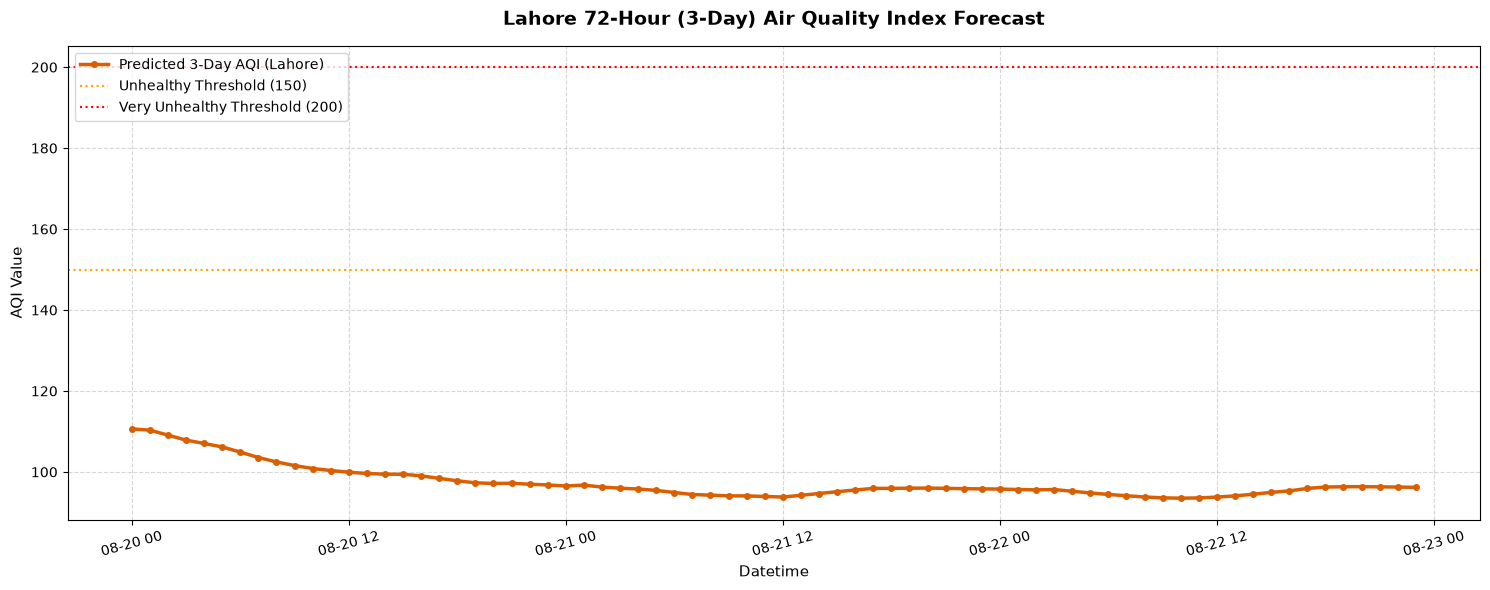

Forecast visualization saved to: ..\data\processed\lahore\lahore_72h_forecast_plot.png


In [9]:
plt.figure(figsize=(15, 6))

# Plot forecast curve
plt.plot(
    forecast_results_df["datetime"],
    forecast_results_df["predicted_aqi"],
    color="#d95f02",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Predicted 3-Day AQI (Lahore)"
)

# Style details
plt.title("Lahore 72-Hour (3-Day) Air Quality Index Forecast", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Datetime", fontsize=11)
plt.ylabel("AQI Value", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# Highlight standard AQI Hazard threshold reference zones
plt.axhline(150, color="orange", linestyle=":", label="Unhealthy Threshold (150)")
plt.axhline(200, color="red", linestyle=":", label="Very Unhealthy Threshold (200)")

plt.legend(loc="upper left")
plt.xticks(rotation=15)
plt.tight_layout()

# Save visualization
plot_save_path = DATA_DIR / "lahore_72h_forecast_plot.png"
plt.savefig(plot_save_path, dpi=150)
plt.show()

print("Forecast visualization saved to:", plot_save_path)

In [10]:
print("=" * 60)
print("             3-DAY FORECAST REPORT SUMMARY")
print("=" * 60)
print("Forecast Run Time:", datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print(f"Predictions from : {forecast_results_df['datetime'].min()}")
print(f"Predictions to   : {forecast_results_df['datetime'].max()}")
print("-" * 60)

# Extract key statistics
max_idx = forecast_results_df["predicted_aqi"].idxmax()
min_idx = forecast_results_df["predicted_aqi"].idxmin()

max_aqi = forecast_results_df.loc[max_idx, "predicted_aqi"]
max_time = forecast_results_df.loc[max_idx, "datetime"]

min_aqi = forecast_results_df.loc[min_idx, "predicted_aqi"]
min_time = forecast_results_df.loc[min_idx, "datetime"]

avg_aqi = forecast_results_df["predicted_aqi"].mean()

print(f"Peak predicted AQI  : {max_aqi:.2f} at {max_time} ({get_aqi_label(max_aqi)})")
print(f"Lowest predicted AQI: {min_aqi:.2f} at {min_time} ({get_aqi_label(min_aqi)})")
print(f"Average predicted AQI: {avg_aqi:.2f} ({get_aqi_label(avg_aqi)})")
print("=" * 60)

             3-DAY FORECAST REPORT SUMMARY
Forecast Run Time: 2026-08-20 12:00:40
Predictions from : 2026-08-20 00:00:00
Predictions to   : 2026-08-22 23:00:00
------------------------------------------------------------
Peak predicted AQI  : 110.63 at 2026-08-20 00:00:00 (Unhealthy for Sensitive Groups)
Lowest predicted AQI: 93.51 at 2026-08-22 10:00:00 (Moderate)
Average predicted AQI: 97.40 (Moderate)
